## 0) Load Packages

In [3]:
# load the necessary packages

%pip install census pandas us

import pandas as pd
import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


from census import Census

Note: you may need to restart the kernel to use updated packages.


# Section I: Scraping and Cleaning NYC Census Data for 2012-2023
## a) call API key & set zip prefixes

In [4]:
# CONFIGURATION 
CENSUS_API_KEY = "490acb0ff4f5c2d42f91ba55b77e4de855d1da8f"
c = Census(CENSUS_API_KEY)

## official NYC ZCTA prefixes (bc accessing full New York County, so need to filter)
NYC_PREFIXES = ('100', '101', '102', '103', '104', '111', '112', '113', '114', '116')

## b) assign variables using a dictionary

In [5]:
VARIABLES = {
        
    'B01003_001E': 'Total_Pop',

    # racial demographics
    'B03002_003E': 'White_NonHisp',
    'B03002_004E': 'Black',
    'B03002_006E': 'Asian',
    'B03002_012E': 'Hispanic',
    
    # income & inequality
    'B19013_001E': 'Median_HH_Inc',
    'B19301_001E': 'Per_Capita_Inc',
    'B19083_001E': 'Gini_Index',
    'B17001_002E': 'Pop_Below_Poverty',
    'B22010_002E': 'HH_on_SNAP',
    
    # housing
    'B25077_001E': 'Med_Home_Value',
    'B25064_001E': 'Med_Gross_Rent',
    'B25003_002E': 'Owner_Occupied',
    'B25003_003E': 'Renter_Occupied',
    'B25002_003E': 'Vacant_Units',
    
    # education & labor
    'B15003_022E': 'Bachelors_Deg',
    'B15003_023E': 'Masters_Deg',
    'B23025_005E': 'Unemployed_Count',
    
    # immigration
    'B05002_013E': 'Foreign_Born',
    'B07001_017E': 'Moved_Last_Year'
}

## c) scraping loop

In [6]:
years_to_pull = list(range(2012, 2023)) 
all_data = []

for y in years_to_pull:
    try:
        print(f"currently craping {y}...")
        
        # copy variables 
        current_vars = VARIABLES.copy()
            
        # FIXED -> need a diff geography request for 2020+
        if y >= 2020:
            # request all ZCTAs (no 'in state' filter)
            geo = {'for': 'zip code tabulation area:*'}
        else:
            # keep state filter to help speed it up
            geo = {'for': 'zip code tabulation area:*', 'in': 'state:36'}

        raw_data = c.acs5.get(tuple(current_vars.keys()), geo, year=y)
        
        df = pd.DataFrame(raw_data)
        df = df.rename(columns=current_vars)
        
        # manually filter for NYC ZIP codes 
        df = df[df['zip code tabulation area'].str.startswith(NYC_PREFIXES)].copy()
        df['year'] = y
        all_data.append(df)
        print(f"✅ success! {y} added.")
        
    except Exception as e:
        print(f"❌ could not get {y}: {e}")


if 'all_data' in locals() and len(all_data) > 0:
    final_nyc_df = pd.concat(all_data, ignore_index=True)
    print(f"Successfully created final_nyc_df with {len(final_nyc_df)} rows.")
else:
    print("Error: 'all_data' is empty. Did you run the scraper loop cell yet?")

currently craping 2012...
✅ success! 2012 added.
currently craping 2013...
✅ success! 2013 added.
currently craping 2014...
✅ success! 2014 added.
currently craping 2015...
✅ success! 2015 added.
currently craping 2016...
✅ success! 2016 added.
currently craping 2017...
✅ success! 2017 added.
currently craping 2018...
✅ success! 2018 added.
currently craping 2019...
✅ success! 2019 added.
currently craping 2020...
✅ success! 2020 added.
currently craping 2021...
✅ success! 2021 added.
currently craping 2022...
✅ success! 2022 added.
Successfully created final_nyc_df with 2299 rows.


## d) clean all NYC data

In [7]:
# standardize column names (year and income casing)
if 'end_year' in final_nyc_df.columns:
    final_nyc_df = final_nyc_df.rename(columns={'end_year': 'year'})

# check and standardize per capita income column to lowercase
final_nyc_df.columns = [c.lower() for c in final_nyc_df.columns]

# add borough names based on ZIP prefixes
def get_borough(zip_code):
    z = str(zip_code)
    if z.startswith('104'): return 'Bronx'
    if z.startswith(('112', '110')): return 'Brooklyn' # 110 is border, usually Brooklyn ZCTA
    if z.startswith(('100', '101', '102')): return 'Manhattan'
    if z.startswith(('111', '113', '114', '116')): return 'Queens'
    if z.startswith('103'): return 'Staten Island'
    return 'Other'

final_nyc_df['borough'] = final_nyc_df['zip code tabulation area'].apply(get_borough)

# Section II: Analyzing all NYC Zips

## a) sort and group

In [8]:
df_sorted = final_nyc_df.sort_values(['zip code tabulation area', 'year'])

# sort and group - UPDATED TO USE MEDIAN HH INCOME
summary_df = df_sorted.groupby(['zip code tabulation area', 'borough']).agg(
    avg_med_hh_inc=('median_hh_inc', 'mean'), # Renamed for clarity
    income_2012=('median_hh_inc', 'first'),   # <--- Change this from per_capita_inc
    income_2022=('median_hh_inc', 'last'),    # <--- Change this from per_capita_inc
    med_HHinc=('median_hh_inc', 'mean')
).reset_index()

## b) calculate changes over time

In [9]:
# calculate changes (now based on Median HH Income, also did this step w per capita income)
summary_df['total_change'] = summary_df['income_2022'] - summary_df['income_2012']
summary_df['pct_growth'] = (summary_df['total_change'] / summary_df['income_2012']) * 100


# avg change per 5-year interval 
summary_df['avg_5yr_change'] = summary_df['total_change'] / 2

# percentage growth
summary_df['pct_growth'] = (summary_df['total_change'] / summary_df['income_2012']) * 100

# filter out unusable data (ZIPs w 0 or missing income in 2012)
summary_df = summary_df[summary_df['income_2012'] > 0].dropna()

# sort by growth
summary_dataframe = summary_df.sort_values(by='total_change', ascending=False)

print(f"Analysis complete for {len(summary_df)} NYC ZIP codes.")
summary_dataframe.head(15)

Analysis complete for 178 NYC ZIP codes.


,zip code tabulation area,borough,avg_med_hh_inc,income_2012,income_2022,med_HHinc,total_change,pct_growth,avg_5yr_change
3,10004,Manhattan,160416.090909,127281.0,232543.0,160416.090909,105262.0,82.700482,52631.0
5,10006,Manhattan,154272.454545,115787.0,204574.0,154272.454545,88787.0,76.681320,44393.5
11,10013,Manhattan,108562.545455,68790.0,150675.0,108562.545455,81885.0,119.036197,40942.5
127,11215,Brooklyn,122499.818182,93184.0,173899.0,122499.818182,80715.0,86.618947,40357.5
67,10280,Manhattan,160004.818182,125830.0,206150.0,160004.818182,80320.0,63.832154,40160.0
129,11217,Brooklyn,105648.818182,78591.0,152735.0,105648.818182,74144.0,94.341591,37072.0
114,11201,Brooklyn,120039.818182,93693.0,163310.0,120039.818182,69617.0,74.303310,34808.5
4,10005,Manhattan,155504.727273,120729.0,189886.0,155504.727273,69157.0,57.282840,34578.5
95,10464,Bronx,89687.454545,61063.0,129109.0,89687.454545,68046.0,111.435730,34023.0
107,11101,Queens,66949.636364,43909.0,109625.0,66949.636364,65716.0,149.664078,32858.0


## c) identify extremes

In [10]:
# identify the specific rows for each extreme
highest_income = summary_df.loc[[summary_df['med_HHinc'].idxmax()]].copy()
lowest_income = summary_df.loc[[summary_df['med_HHinc'].idxmin()]].copy()
biggest_change = summary_df.loc[[summary_df['total_change'].idxmax()]].copy()
smallest_change = summary_df.loc[[summary_df['total_change'].idxmin()]].copy()

# add a 'Category' label to each so we know why they are in this table
highest_income['Metric'] = 'Highest Avg Income'
lowest_income['Metric'] = 'Lowest Avg Income'
biggest_change['Metric'] = 'Biggest Dollar Growth'
smallest_change['Metric'] = 'Smallest Growth'

# combine them into the mini-dataframe
extremes_df = pd.concat([highest_income, lowest_income, biggest_change, smallest_change])

# clean up the view 
## reordering columns to put the label first
cols = ['Metric', 'zip code tabulation area', 'borough', 'med_HHinc', 'total_change', 'pct_growth']
extremes_df = extremes_df[cols].reset_index(drop=True)

# formatting (adding $ and rounding)
pd.options.display.float_format = '${:,.2f}'.format
print("--- NYC Income Extremes (2012-2022) ---")
print(extremes_df)

--- NYC Income Extremes (2012-2022) ---
                  Metric zip code tabulation area    borough   med_HHinc  \
0     Highest Avg Income                    10282  Manhattan $246,356.82   
1      Lowest Avg Income                    10454      Bronx  $21,502.09   
2  Biggest Dollar Growth                    10004  Manhattan $160,416.09   
3        Smallest Growth                    10162  Manhattan $156,831.45   

   total_change  pct_growth  
0    $16,592.00       $7.11  
1     $7,129.00      $36.99  
2   $105,262.00      $82.70  
3   $-60,526.00     $-36.48  


# Section III: Comparing and Selecting Brooklyn ZIPs for Further Analysis
## a) filter

In [11]:
# we need to update the filter: only include '112'
def get_borough(zip_code):
    z = str(zip_code)
    if z.startswith('112'): return 'Brooklyn'  # Removed '110' here
    if z.startswith('104'): return 'Bronx'
    if z.startswith(('100', '101', '102')): return 'Manhattan'
    if z.startswith(('111', '113', '114', '116')): return 'Queens'
    if z.startswith('103'): return 'Staten Island'
    return 'Other'

# re-apply the borough labels to the summary dataframe
summary_df['borough'] = summary_df['zip code tabulation area'].apply(get_borough)

# filter for Brooklyn ONLY 
bk_only = summary_df[summary_df['borough'] == 'Brooklyn'].copy()

## b) identify extremes

In [12]:
# using .nlargest() and .nsmallest() to get more than one row
highest_income_bk = bk_only.nlargest(3, 'med_HHinc').copy()
lowest_income_bk  = bk_only.nsmallest(3, 'med_HHinc').copy()
biggest_change_bk = bk_only.nlargest(3, 'total_change').copy()
smallest_change_bk = bk_only.nsmallest(3, 'total_change').copy()

# add the metric labels
highest_income_bk['Metric'] = 'Highest Med HH Income'
lowest_income_bk['Metric']  = 'Lowest Med HH Income'
biggest_change_bk['Metric'] = 'Biggest Dollar Growth'
smallest_change_bk['Metric'] = 'Smallest Growth'

# combine into one dataframe
extremes_bk_df = pd.concat([highest_income_bk, lowest_income_bk, biggest_change_bk, smallest_change_bk])

# reorder columns 
cols = ['Metric', 'zip code tabulation area', 'med_HHinc', 'total_change', 'pct_growth']
extremes_bk_df = extremes_bk_df[cols].reset_index(drop=True)

# print!
print("--- BROOKLYN ZIP CODE EXTREMES (TOP 3 PER CATEGORY) ---")
print(extremes_bk_df)

--- BROOKLYN ZIP CODE EXTREMES (TOP 3 PER CATEGORY) ---
                   Metric zip code tabulation area   med_HHinc  total_change  \
0   Highest Med HH Income                    11215 $122,499.82    $80,715.00   
1   Highest Med HH Income                    11201 $120,039.82    $69,617.00   
2   Highest Med HH Income                    11249 $109,584.00     $8,724.00   
3    Lowest Med HH Income                    11239  $28,532.00    $14,030.00   
4    Lowest Med HH Income                    11212  $28,681.09     $7,939.00   
5    Lowest Med HH Income                    11224  $32,370.73     $9,052.00   
6   Biggest Dollar Growth                    11215 $122,499.82    $80,715.00   
7   Biggest Dollar Growth                    11217 $105,648.82    $74,144.00   
8   Biggest Dollar Growth                    11201 $120,039.82    $69,617.00   
9         Smallest Growth                    11212  $28,681.09     $7,939.00   
10        Smallest Growth                    11249 $109,584.00  

## c) compare brooklyn zips

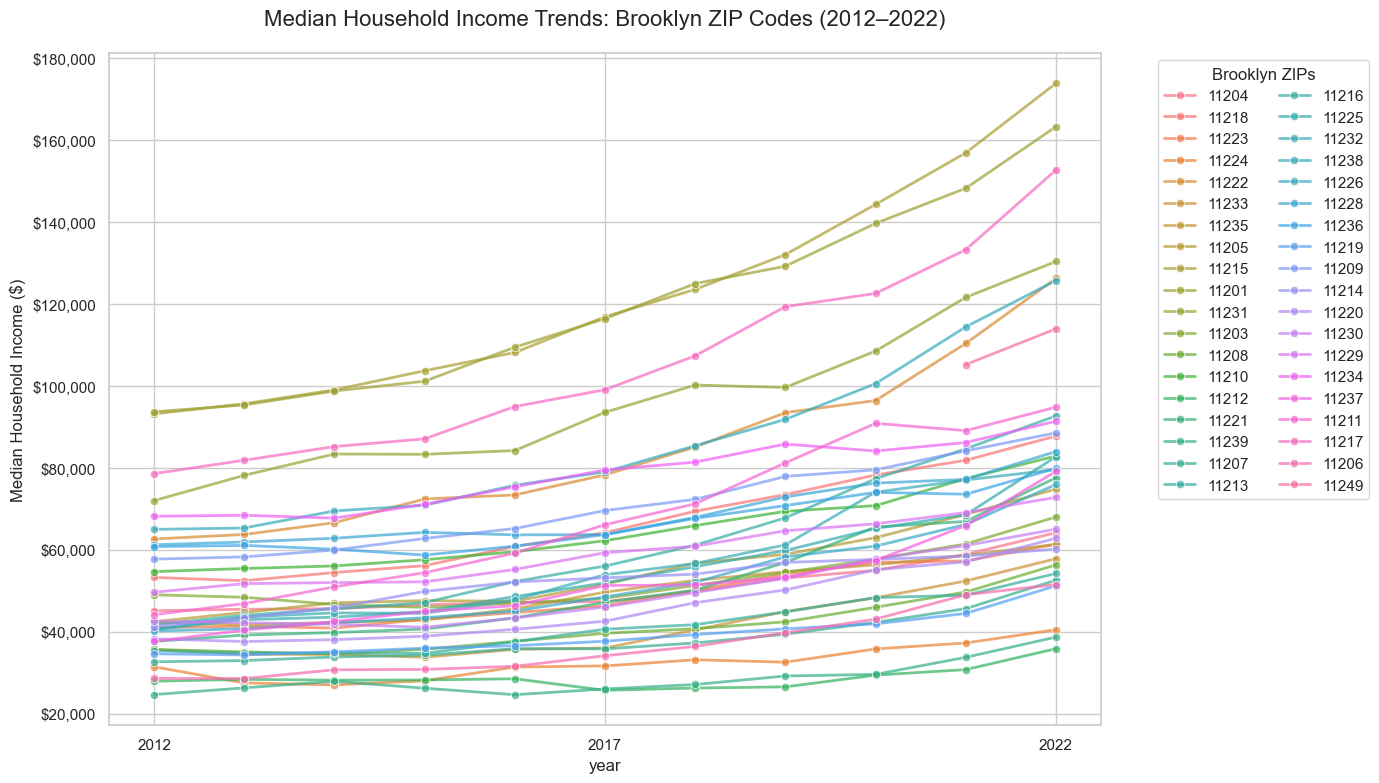

In [13]:
# clean and standardize (just in case)
final_nyc_df.columns = [c.lower() for c in final_nyc_df.columns]
if 'end_year' in final_nyc_df.columns:
    final_nyc_df = final_nyc_df.rename(columns={'end_year': 'year'})

# apply brooklyn filter (again...)
def get_borough(zip_code):
    z = str(zip_code)
    if z.startswith(('112', '110')): return 'Brooklyn'
    return 'Other'

final_nyc_df['borough'] = final_nyc_df['zip code tabulation area'].apply(get_borough)
bk_df = final_nyc_df[final_nyc_df['borough'] == 'Brooklyn'].copy()

# create the plot 
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

plot = sns.lineplot(
    data=bk_df, 
    x='year', 
    y='median_hh_inc',  # also explored using per_capita_inc
    hue='zip code tabulation area', 
    marker='o', 
    linewidth=2,
    alpha=0.7
)

# update labels
plt.title('Median Household Income Trends: Brooklyn ZIP Codes (2012–2022)', fontsize=16, pad=20)
plt.ylabel('Median Household Income ($)', fontsize=12)
plt.xticks([2012, 2017, 2022])

# move the legend so it doesn't cover the lines
plt.legend(title='Brooklyn ZIPs', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# format y-axis with Dollar Signs
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

## d) plotting for comparison

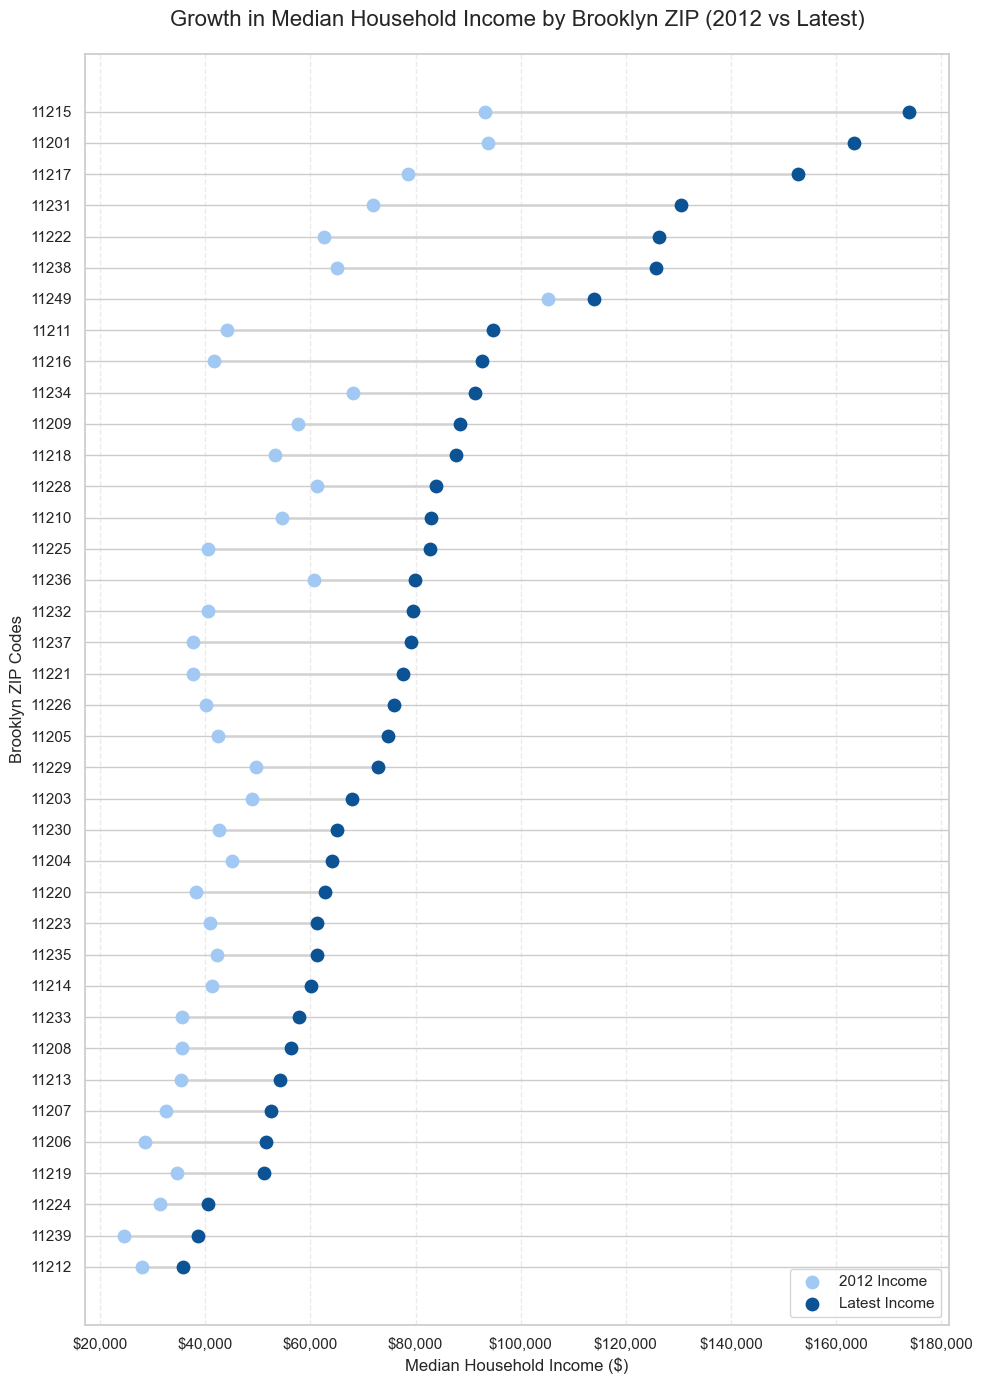

In [14]:
# sort by latest income 
df_plot = bk_only.sort_values('income_2022').copy()

plt.figure(figsize=(10, 14)) 

# create the lines 
plt.hlines(y=df_plot['zip code tabulation area'], 
           xmin=df_plot['income_2012'], 
           xmax=df_plot['income_2022'], 
           color='lightgrey', linewidth=2, alpha=0.8)

# plot the 2012 points (starting point)
plt.scatter(df_plot['income_2012'], df_plot['zip code tabulation area'], 
            color='#a1c9f4', label='2012 Income', s=80, zorder=3)

# plot the latest points (ending point)
plt.scatter(df_plot['income_2022'], df_plot['zip code tabulation area'], 
            color='#0b5394', label='Latest Income', s=80, zorder=3)



# formatting
plt.title('Growth in Median Household Income by Brooklyn ZIP (2012 vs Latest)', fontsize=16, pad=20)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Brooklyn ZIP Codes', fontsize=12)
plt.legend(loc='lower right')

## format x-axis as Dollars
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## e) save relevant columns on selected zips

In [15]:
# combine and clean all scraped years
final_nyc_df = pd.concat(all_data, ignore_index=True)

final_nyc_df.columns = [c.lower().replace(' ', '_') for c in final_nyc_df.columns]
final_nyc_df = final_nyc_df.loc[:, ~final_nyc_df.columns.duplicated()] # Remove double columns


# handle census error codes & Pop=0
census_error_codes = [-666666666, -888888888, -999999999]
final_nyc_df = final_nyc_df.replace(census_error_codes, np.nan)
final_nyc_df = final_nyc_df[final_nyc_df['total_pop'] > 0]


# filter to 3 selected ZIPs
target_zips = ['11212', '11215', '11237']
final_nyc_df['zip_code_tabulation_area'] = final_nyc_df['zip_code_tabulation_area'].astype(str).str.strip()
three_zips_df = final_nyc_df[final_nyc_df['zip_code_tabulation_area'].isin(target_zips)].copy()


# final formatting
three_zips_df['year'] = three_zips_df['year'].astype(int)
three_zips_df = three_zips_df.sort_values(['zip_code_tabulation_area', 'year'])

# save as csv
three_zips_df.to_csv('brooklyn_selected_zips.csv', index=False)

# triple check one more time that all the rows made it
print(f"Done! Saved {len(three_zips_df)} rows.")

Done! Saved 33 rows.
